# 港股通ETF：日内价差与当日净新增份额

研究区间2025-07至2026-06。用户指定当日最终结算率固定全天；不估计隐藏双边申赎量。结果与完整方法见同目录研究报告。

## 方法与来源

主标签：净增至少10篮子，且至少为前一日份额的0.5%。训练期2025年7—12月，验证期2026年1—3月，测试期2026年4—6月。网站份额日期直接对应业务日，不作平移。

股票分钟、ETF分钟、PCF路径和排除规则见README.md；汇率源为中国货币网中间价及沪深交易所日终结算汇兑比率。完整原始行情在machome处理。结果使用当前站内标的名单，存在存续标的选择偏差。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
R=Path.cwd()
O=R/'results'
plt.rcParams.update({'figure.figsize':(12,5), 'font.size':11, 'axes.spines.top':False, 'axes.spines.right':False})
font=Path('/System/Library/Fonts/Supplemental/Arial Unicode.ttf')
if font.exists():
    font_manager.fontManager.addfont(str(font))
    plt.rcParams['font.family']=font_manager.FontProperties(fname=str(font)).get_name()
plt.rcParams['axes.unicode_minus']=False
audit=json.loads((O/'panel_audit.json').read_text())
print({k:audit[k] for k in ['rows','funds','dates']})

{'rows': 32447, 'funds': 191, 'dates': 234}


## 样本和基准

每行是一个基金-交易日，纳入全天所有有效重叠交易分钟；本轮共32,447个基金日、7,787,280个分钟观测。

In [2]:
baseline=pd.read_csv(O/'baselines.csv')
display(baseline[baseline.split=='test'][['cut','n','funds','days','positive_rate','large_rate','negative_rate']].round(4))

,cut,n,funds,days,positive_rate,large_rate,negative_rate
2,all_day,8940,175,57,0.1012,0.0331,0.3612


## 三组序列样例

159570.SZ，2025-07-02，固定当日最终汇率。时间戳保守延后一分；午休与闭市后ETF价格留空。此图用于核对重建，不是事后挑选的盈利交易。

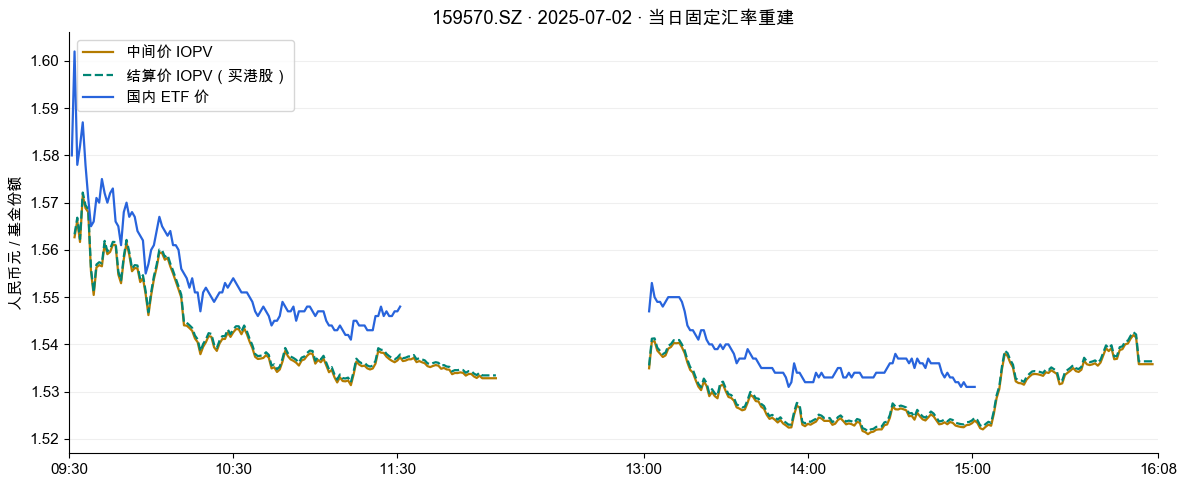

In [3]:
sample_path=O/'series'/'20250702.parquet'
if sample_path.exists():
    s=pd.read_parquet(sample_path)
    s=s[s.symbol=='159570.SZ'].copy()
    s.to_csv(O/'sample_159570_20250702.csv',index=False)
else:
    s=pd.read_csv(O/'sample_159570_20250702.csv')
assert len(s)>0
x=pd.to_datetime(s['date']+' '+s.minute)
fig,ax=plt.subplots(figsize=(12,5))
for field,label,color,style in [('mid','中间价 IOPV','#b47b00','-'),('actual_settlement_buy','结算价 IOPV（买港股）','#008575','--'),('etf','国内 ETF 价','#2864dc','-')]:
    ax.plot(x,s[field],label=label,color=color,linestyle=style,linewidth=1.6)
ax.set_title('159570.SZ · 2025-07-02 · 当日固定汇率重建')
ax.set_ylabel('人民币元 / 基金份额')
ax.grid(axis='y',alpha=.2)
ax.legend(loc='upper left')
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xticks(pd.to_datetime(['2025-07-02 '+t for t in ['09:30','10:30','11:30','13:00','14:00','15:00','16:08']]))
ax.set_xlim(x.iloc[0],x.iloc[-1])
fig.tight_layout()
fig.savefig(O/'sample_three_series.png',dpi=160)
plt.show()

## 结算溢价因子的跨期分桶

分桶边界只用训练期确定；下面展示全天路径在测试期的各桶命中率。每桶分母为该桶基金日数量。

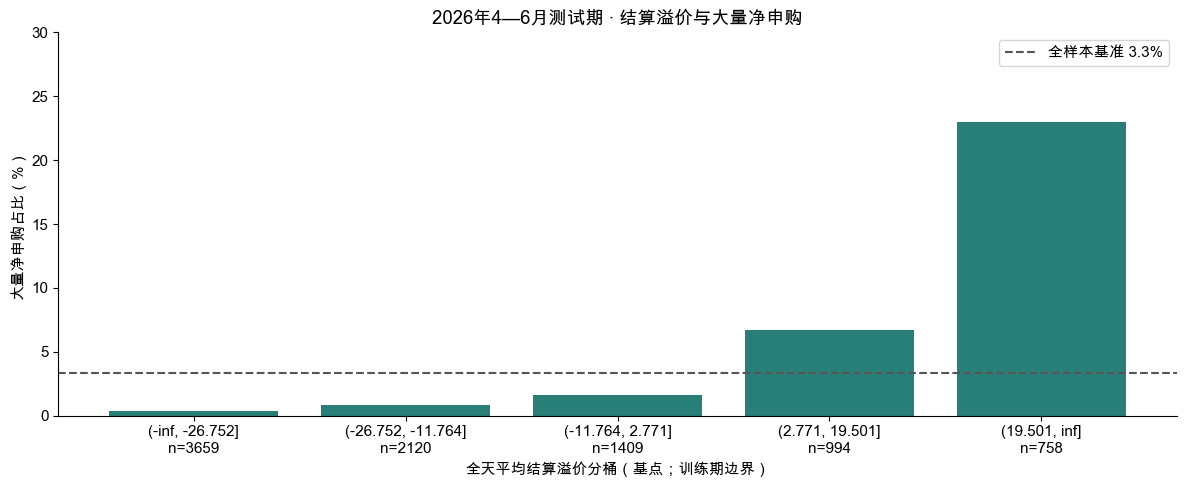

,bucket,n,funds,large_rate,positive_rate,negative_rate
220,"(-inf, -26.752]",3659,174,0.0038,0.0120,0.5805
221,"(-26.752, -11.764]",2120,169,0.0085,0.0335,0.2868
222,"(-11.764, 2.771]",1409,161,0.0163,0.0880,0.2044
223,"(2.771, 19.501]",994,142,0.0674,0.2525,0.1398
224,"(19.501, inf]",758,107,0.2296,0.5475,0.0923


In [4]:
buckets=pd.read_csv(O/'factor_buckets.csv')
b=buckets[(buckets.cut=='all_day')&(buckets.feature=='settlement_mean_bp')&(buckets.split=='test')].copy()
assert len(b)>0
fig,ax=plt.subplots(figsize=(12,5))
ax.bar(np.arange(len(b)),b.large_rate*100,color='#287f78')
base=baseline[(baseline.cut=='all_day')&(baseline.split=='test')].large_rate.iloc[0]*100
ax.axhline(base,color='#555555',linestyle='--',label=f'全样本基准 {base:.1f}%')
ax.set_xticks(np.arange(len(b)),[str(t)+'\nn='+str(n) for t,n in zip(b.bucket,b.n)])
ax.set_xlabel('全天平均结算溢价分桶（基点；训练期边界）')
ax.set_ylabel('大量净申购占比（%）')
ax.set_title('2026年4—6月测试期 · 结算溢价与大量净申购')
ax.set_ylim(0,max(30,(b.large_rate.max()*100+5)))
ax.legend()
fig.tight_layout()
fig.savefig(O/'factor_bucket_test.png',dpi=160)
plt.show()
display(b[['bucket','n','funds','large_rate','positive_rate','negative_rate']].round(4))

## 验证期选定条件的测试结果

规则与模型的选择均不使用测试期标签；不是将全部条件中的测试最好值当作结果。概率区间按交易日聚类重采样。

In [5]:
choices=json.loads((O/'selected_conditions.json').read_text())
summary=[]
for r in choices:
    summary.append(dict(cut=r['cut'],kind=r['kind'],name=r['name'],**r['test']))
display(pd.DataFrame(summary).round(4))

,cut,kind,name,n,funds,days,positive_rate,negative_rate,large_rate,median_net_baskets,mean_net_flow_pct,median_net_flow_pct
0,all_day,rule,mean30_and_positive_yesterday,197,54,46,0.8223,0.0457,0.4467,10.0,2.2835,1.0309
1,all_day,model,hist_gradient,265,48,51,0.7774,0.0792,0.5094,21.0,1.7028,0.7352


## 数据核对与限制

实际结算率是用户指定的日内固定事后参数，所以时间切分证明的是跨期条件关联，不能直接宣称盘中可执行或已经取得套利收益。多数新基金历史不足一年；缺少成分或标签的基金日明确剔除。

In [6]:
q=pd.read_csv(O/'pcf_nav_reconciliation.csv')
print('上一日净值复核绝对偏差（基点）')
display(q.difference_bp.abs().quantile([.5,.9,.95,.99]).round(3))
print('缺失/异常排除统计')
display(pd.DataFrame(list(audit['excluded_reasons'].items()),columns=['reason','count']))

上一日净值复核绝对偏差（基点）


0.50     0.281
0.90     3.165
0.95    12.523
0.99    40.179
Name: difference_bp, dtype: float64

缺失/异常排除统计


,reason,count
0,missing_hk_etf_or_midpoint,7
1,missing_label,43
2,missing_hk_component,1987
3,label_previous_date_mismatch,102
4,missing_etf,5
5,etf_iopv_ratio_outlier,141
